In [1]:
# barchart for tree

In [19]:
import os
import re
import numpy as np
import pandas as pd

from scipy.stats import zscore

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

In [20]:
# input file
input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

In [21]:
# z-scores combined for VACV, VARV, TPV, and RCV
def zscore_df(df, cond_list):
    """Generates a combined z-score for the specified list of K3 conditions"""
    
    temp_df = df.pivot_table(
        index=['pkr'],
        columns='k3',
        values='auc_mean',
        dropna=False
    )
    
    temp_df.reset_index(inplace=True)
    temp_df.index.name = None

    site_map = dict(zip(df['pkr'], df['site']))
    wt_map = dict(zip(df['pkr'], df['wt_aa']))
    var_map = dict(zip(df['pkr'], df['var_aa']))

    temp_df['site'] = temp_df['pkr'].map(site_map)
    temp_df['wt_aa'] = temp_df['pkr'].map(wt_map)
    temp_df['var_aa'] = temp_df['pkr'].map(var_map)
    
    z_cols = []
    for cond in cond_list:
        z_col = f"{cond} z-score"
        z_cols.append(z_col)
        temp_df[z_col] = zscore(temp_df[cond])
    
    k = len(z_cols)
    temp_df['combined z-scores'] = temp_df.apply(lambda row: row[z_cols].sum() / np.sqrt(k), axis=1)

    return temp_df

# heatmap for all conditions
cond_list = ['VACV K3','VARV C3','TPV K3', 'RCVZ vIF2α']
temp_df = zscore_df(df, cond_list)

In [22]:
# establish bins with relevant hex colors
def custom_cmap(cmap_name, center, vmin, vmax):
    """Pulled from seaborn matrix.py to center cmap on WT value"""
    cmap = mpl.colormaps[cmap_name]
    under = cmap(-np.inf)
    over = cmap(np.inf)
    under_set = under != cmap(0)
    over_set = over != cmap(cmap.N - 1)

    vrange = max(vmax - center, center - vmin)
    normlize = mpl.colors.Normalize(center - vrange, center + vrange)
    cmin, cmax = normlize([vmin, vmax])
    cc = np.linspace(cmin, cmax, 256)
    cmap = mpl.colors.ListedColormap(cmap(cc))
    cmap.set_bad(color='gainsboro')
    if under_set:
        cmap.set_under(under)
    if over_set:
        cmap.set_over(over)

    return cmap

cmap_color = 'seismic_r'
center = temp_df.query('pkr == "PKR-WT"').iloc[0]['combined z-scores']   # WT combined z-score
vmin = temp_df['combined z-scores'].min()
vmax = temp_df['combined z-scores'].max()       # full-data range
cmap = custom_cmap(cmap_color, center, vmin, vmax)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# N_BINS bins placed SYMMETRICALLY about the WT center, so the middle
# bin's midpoint == center and therefore renders white.
N_BINS = 9
R = max(center - vmin, vmax - center)          # reach to the farther extreme
edges = np.linspace(center - R, center + R, N_BINS + 1)
mids = (edges[:-1] + edges[1:]) / 2.0
bin_hex   = [mcolors.rgb2hex(cmap(norm(m))) for m in mids]        # one color/bin
bin_range = [f'[{edges[i]:.2f}, {edges[i+1]:.2f})' for i in range(N_BINS)]

# assign any z-score to a bin index (0 .. N_BINS-1)
def z_to_bin(v):
    return int(np.clip(np.digitize([v], edges)[0] - 1, 0, N_BINS - 1))

temp_df['z_bin'] = temp_df.apply(lambda row: z_to_bin(row['combined z-scores']), axis=1)

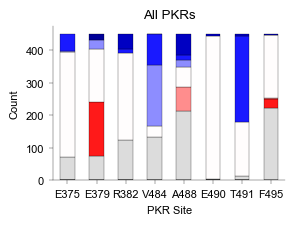

In [54]:
# now load Meru's variant count tables
def load_counts(path):
    """Parse the $-delimited count blocks into a long DataFrame.

    Each block is a header (e.g. '$E375K' -> WT E, site 375) followed by a
    row of amino-acid letters and a row of counts.
    """
    rows = []
    for block in open(path).read().split('$'):
        if not block.strip():
            continue
        lines = [l for l in block.splitlines() if l.strip()]
        m = re.match(r'([A-Z])(\d+)', lines[0].strip())   # WT residue + position
        wt_aa, site = m.group(1), int(m.group(2))
        aas    = lines[1].split()                         # letters row ('-' = gap)
        counts = [int(x) for x in lines[2].split()]       # counts row
        for aa, ct in zip(aas, counts):
            rows.append({'site': site, 'wt_aa': wt_aa, 'aa': aa, 'count': ct})

    df = pd.DataFrame(rows)
    df['is_wt']  = df['aa'] == df['wt_aa']
    df['is_gap'] = df['aa'] == '-'
    return df

df1 = load_counts('all PKRs.txt')

# map the variants to the proper z-bin
# merge the z_bin ids for variants
df1 = df1.merge(
    temp_df[['site', 'var_aa', 'z_bin']],
    left_on=['site', 'aa'], right_on=['site', 'var_aa'],
    how='left',
)

# and generate a stacked barplot
interest_sites = [375,379,382,484,488,490,491,495]
df1.query('site.isin(@interest_sites)', inplace=True)
# replace wt z_bin with 4
df1.loc[df1['is_wt'], 'z_bin'] = 4 

df1.z_bin.replace(np.nan, -1, inplace=True)
df2 = df1.groupby(['site','z_bin'])['count'].sum().reset_index()

# pivot table for pandas plot
df3 = df2.pivot(index='site', columns='z_bin', values='count')

color_dict = {-1.:'#dcdcdc',0.:'#9a0000',1.:'#d30000',2.:'#ff1919',3.:'#ff8d8d',4.:'#fffdfd',5.:'#8d8dff',6.:'#1919ff',7.:'#0000c2',8.:'#000098',}
x_labels = {375:'E375', 379:'E379',382:'R382',484:'V484',488:'A488',490:'E490',491:'T491',495:'F495'}
new_labels = ['E375','E379','R382','V484','A488','E490','T491','F495']


width_in = 3
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = .1
marker_diameter = 3 # 1.75

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
#plt.figure(figsize=(width_in, height_in)) # save size

fig, ax = plt.subplots(figsize=(width_in, height_in))
ax = df3.plot.bar(
    stacked=True,
    color= color_dict,
    linewidth=.2,
    edgecolor='black',
    legend=False,
    ax=ax
)

ax.set_xticks(range(len(new_labels)))
ax.set_xticklabels(new_labels)
ax.tick_params(axis="x", labelrotation=0)

# Set font properties for axis labels
ax.set_title('All PKRs')
ax.set_xlabel(f'PKR Site', fontsize=font_size, fontname=font_name)
ax.set_ylabel(f'Count', fontsize=font_size, fontname=font_name)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)


#plt.tight_layout()
fig = ax.get_figure()
fig.savefig(f'../../img/variant_tree/barplot_all-PKRs.svg', format='svg', bbox_inches='tight', transparent=False)
plt.show()

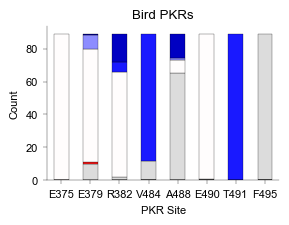

In [52]:
# now load Meru's variant count tables
def load_counts(path):
    """Parse the $-delimited count blocks into a long DataFrame.

    Each block is a header (e.g. '$E375K' -> WT E, site 375) followed by a
    row of amino-acid letters and a row of counts.
    """
    rows = []
    for block in open(path).read().split('$'):
        if not block.strip():
            continue
        lines = [l for l in block.splitlines() if l.strip()]
        m = re.match(r'([A-Z])(\d+)', lines[0].strip())   # WT residue + position
        wt_aa, site = m.group(1), int(m.group(2))
        aas    = lines[1].split()                         # letters row ('-' = gap)
        counts = [int(x) for x in lines[2].split()]       # counts row
        for aa, ct in zip(aas, counts):
            rows.append({'site': site, 'wt_aa': wt_aa, 'aa': aa, 'count': ct})

    df = pd.DataFrame(rows)
    df['is_wt']  = df['aa'] == df['wt_aa']
    df['is_gap'] = df['aa'] == '-'
    return df

df1 = load_counts('bird PKRs.txt')

# map the variants to the proper z-bin
# merge the z_bin ids for variants
df1 = df1.merge(
    temp_df[['site', 'var_aa', 'z_bin']],
    left_on=['site', 'aa'], right_on=['site', 'var_aa'],
    how='left',
)

# and generate a stacked barplot
interest_sites = [375,379,382,484,488,490,491,495]
df1.query('site.isin(@interest_sites)', inplace=True)
# replace wt z_bin with 4
df1.loc[df1['is_wt'], 'z_bin'] = 4 

df1.z_bin.replace(np.nan, -1, inplace=True)
df2 = df1.groupby(['site','z_bin'])['count'].sum().reset_index()

# pivot table for pandas plot
df3 = df2.pivot(index='site', columns='z_bin', values='count')

color_dict = {-1.:'#dcdcdc',0.:'#9a0000',1.:'#d30000',2.:'#ff1919',3.:'#ff8d8d',4.:'#fffdfd',5.:'#8d8dff',6.:'#1919ff',7.:'#0000c2',8.:'#000098',}
x_labels = {375:'E375', 379:'E379',382:'R382',484:'V484',488:'A488',490:'E490',491:'T491',495:'F495'}
new_labels = ['E375','E379','R382','V484','A488','E490','T491','F495']


width_in = 3
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = .1
marker_diameter = 3 # 1.75

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
#plt.figure(figsize=(width_in, height_in)) # save size

fig, ax = plt.subplots(figsize=(width_in, height_in))
ax = df3.plot.bar(
    stacked=True,
    color= color_dict,
    linewidth=.2,
    edgecolor='black',
    legend=False,
    ax=ax
)

ax.set_xticks(range(len(new_labels)))
ax.set_xticklabels(new_labels)
ax.tick_params(axis="x", labelrotation=0)

# Set font properties for axis labels
ax.set_title('Bird PKRs')
ax.set_xlabel(f'PKR Site', fontsize=font_size, fontname=font_name)
ax.set_ylabel(f'Count', fontsize=font_size, fontname=font_name)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)


#plt.tight_layout()
fig = ax.get_figure()
fig.savefig(f'../../img/variant_tree/barplot_birds.svg', format='svg', bbox_inches='tight', transparent=False)
plt.show()

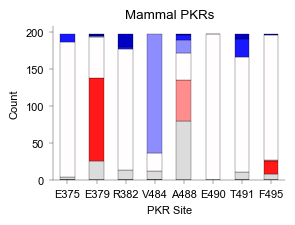

In [51]:
# now load Meru's variant count tables
def load_counts(path):
    """Parse the $-delimited count blocks into a long DataFrame.

    Each block is a header (e.g. '$E375K' -> WT E, site 375) followed by a
    row of amino-acid letters and a row of counts.
    """
    rows = []
    for block in open(path).read().split('$'):
        if not block.strip():
            continue
        lines = [l for l in block.splitlines() if l.strip()]
        m = re.match(r'([A-Z])(\d+)', lines[0].strip())   # WT residue + position
        wt_aa, site = m.group(1), int(m.group(2))
        aas    = lines[1].split()                         # letters row ('-' = gap)
        counts = [int(x) for x in lines[2].split()]       # counts row
        for aa, ct in zip(aas, counts):
            rows.append({'site': site, 'wt_aa': wt_aa, 'aa': aa, 'count': ct})

    df = pd.DataFrame(rows)
    df['is_wt']  = df['aa'] == df['wt_aa']
    df['is_gap'] = df['aa'] == '-'
    return df

df1 = load_counts('mammal PKRs.txt')

# map the variants to the proper z-bin
# merge the z_bin ids for variants
df1 = df1.merge(
    temp_df[['site', 'var_aa', 'z_bin']],
    left_on=['site', 'aa'], right_on=['site', 'var_aa'],
    how='left',
)

# and generate a stacked barplot
interest_sites = [375,379,382,484,488,490,491,495]
df1.query('site.isin(@interest_sites)', inplace=True)
# replace wt z_bin with 4
df1.loc[df1['is_wt'], 'z_bin'] = 4 

df1.z_bin.replace(np.nan, -1, inplace=True)
df2 = df1.groupby(['site','z_bin'])['count'].sum().reset_index()

# pivot table for pandas plot
df3 = df2.pivot(index='site', columns='z_bin', values='count')

color_dict = {-1.:'#dcdcdc',0.:'#9a0000',1.:'#d30000',2.:'#ff1919',3.:'#ff8d8d',4.:'#fffdfd',5.:'#8d8dff',6.:'#1919ff',7.:'#0000c2',8.:'#000098',}
x_labels = {375:'E375', 379:'E379',382:'R382',484:'V484',488:'A488',490:'E490',491:'T491',495:'F495'}
new_labels = ['E375','E379','R382','V484','A488','E490','T491','F495']


width_in = 3
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = .1
marker_diameter = 3 # 1.75

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
#plt.figure(figsize=(width_in, height_in)) # save size

fig, ax = plt.subplots(figsize=(width_in, height_in))
ax = df3.plot.bar(
    stacked=True,
    color= color_dict,
    linewidth=.2,
    edgecolor='black',
    legend=False,
    ax=ax
)

ax.set_xticks(range(len(new_labels)))
ax.set_xticklabels(new_labels)
ax.tick_params(axis="x", labelrotation=0)

# Set font properties for axis labels
ax.set_title('Mammal PKRs')
ax.set_xlabel(f'PKR Site', fontsize=font_size, fontname=font_name)
ax.set_ylabel(f'Count', fontsize=font_size, fontname=font_name)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)


#plt.tight_layout()
fig = ax.get_figure()
fig.savefig(f'../../img/variant_tree/barplot_mammal.svg', format='svg', bbox_inches='tight', transparent=False)
plt.show()

In [79]:
# now make the score curve for sites: 484, 490, 491
def zscore_df(df, cond_list):
    """Generates a combined z-score for the specified list of K3 conditions"""
    
    temp_df = df.pivot_table(
        index=['pkr'],
        columns='k3',
        values='auc_mean',
        dropna=False
    )
    
    temp_df.reset_index(inplace=True)
    temp_df.index.name = None

    site_map = dict(zip(df['pkr'], df['site']))
    wt_map = dict(zip(df['pkr'], df['wt_aa']))
    var_map = dict(zip(df['pkr'], df['var_aa']))
    type_map = dict(zip(df['pkr'], df['pkr_type']))

    temp_df['site'] = temp_df['pkr'].map(site_map)
    temp_df['wt_aa'] = temp_df['pkr'].map(wt_map)
    temp_df['var_aa'] = temp_df['pkr'].map(var_map)
    temp_df['pkr_type'] = temp_df['pkr'].map(type_map)
    
    z_cols = []
    for cond in cond_list:
        z_col = f"{cond} z-score"
        z_cols.append(z_col)
        temp_df[z_col] = zscore(temp_df[cond])
    
    k = len(z_cols)
    temp_df['combined z-scores'] = temp_df.apply(lambda row: row[z_cols].sum() / np.sqrt(k), axis=1)

    return temp_df

# heatmap for all conditions
cond_list = ['VACV K3','VARV C3','TPV K3', 'RCVZ vIF2α']
temp_df = zscore_df(df, cond_list)

In [80]:
# make meru curve

# sort residuals
temp_df.sort_values('combined z-scores', inplace=True, ascending=False)
temp_df['residual_order'] = range(len(temp_df))

# color specific sites
color_dict = {484:'#fe6100',490:'#dc267f',491:'#648fff'}
temp_df['site_color'] = temp_df['site'].map(color_dict).fillna('gainsboro')

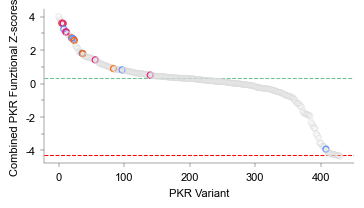

In [85]:
# add linewidth for points
interest_sites = [484,490,491]
big_markers = 1
small_markers = .25
line_dict = {True:big_markers,False:small_markers}
temp_df['linewidth'] = temp_df['site'].isin(interest_sites).map(line_dict)

# Format Plot
width_in = 4
height_in = 2
font_size = 8
font = 'Arial'
stroke = .25
tick_len = 3
alpha_val = .2
marker_diameter = 3 # 3
#ymin = -5
#ymax=5.9

font = {'family': font, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
plt.figure(figsize=(width_in, height_in)) # save size

#fig, ax = plt.subplots()

ax = sns.scatterplot(
    data=temp_df,
    y='combined z-scores',
    x='residual_order',
    size=3,
    legend=False,
    alpha=1,
    facecolor='none',
    edgecolor=temp_df['site_color'],
    linewidth=temp_df['linewidth']
)

# modify plot spines
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set major ticks at even numbers and label as integers
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(2))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

# Show minor ticks for every integer
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))

# Set major tick length
ax.tick_params(axis='both', direction='out', length=tick_len, width=stroke)
plt.gca().yaxis.set_tick_params(width=stroke, which='both', direction='out')

# dashed horizontal lines
hline_wt = temp_df.query('pkr_type == "WT"')['combined z-scores'].values[0]
plt.axhline(y=hline_wt, color='#6dc091', linestyle='--', linewidth=.75, zorder=0)

hline_non = temp_df.query('pkr_type == "Nonsense"')['combined z-scores'].mean()
plt.axhline(y=hline_non, color='red', linestyle='--', linewidth=.75, zorder=0)

# Add labels and title
plt.xlabel('PKR Variant')
plt.ylabel(f'Combined PKR Funztional Z-scores')

# Show plot
plt.show()

fig = ax.get_figure()

# save plot
plot_name = f'score-curve_z-scores_484-490-491.svg'
save_dir = '../../img/score-curves'
output_file = os.path.join(save_dir, plot_name)
fig.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

In [84]:
temp_df.query('pkr_type == "Nonsense"')['combined z-scores'].mean()

-4.298723272726467

In [87]:
hline_non

-4.298723272726467

In [76]:
df3

z_bin,-1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
site,,,,,,,,
375,72.0,NaN,NaN,323.0,1.0,54.0,NaN,NaN
379,76.0,166.0,NaN,161.0,29.0,NaN,NaN,18.0
382,125.0,NaN,NaN,265.0,NaN,12.0,48.0,NaN
484,134.0,NaN,NaN,32.0,189.0,94.0,1.0,NaN
488,212.0,NaN,74.0,61.0,23.0,14.0,66.0,NaN
490,3.0,NaN,NaN,441.0,NaN,NaN,6.0,NaN
491,13.0,NaN,NaN,165.0,NaN,265.0,7.0,NaN
495,222.0,28.0,4.0,192.0,1.0,NaN,3.0,NaN


In [78]:
df3.sum(axis=1)

site
375    450.0
379    450.0
382    450.0
484    450.0
488    450.0
490    450.0
491    450.0
495    450.0
dtype: float64